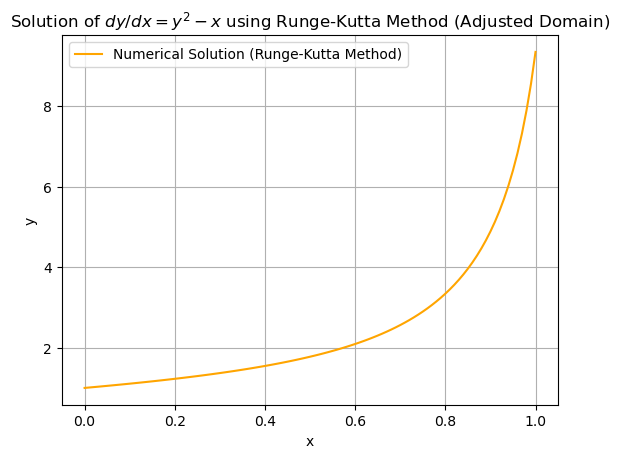

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Function representing the ODE dy/dx = y^2 - x
def dydx(x, y):
    return y**2 - x

# Fourth-order Runge-Kutta method for numerical solution of ODE
def runge_kutta_method(dydx, x0, y0, x_end, h):
    x_values = np.arange(x0, x_end + h, h)
    y_values = np.zeros(len(x_values))
    y_values[0] = y0
    
    for i in range(1, len(x_values)):
        x = x_values[i-1]
        y = y_values[i-1]
        
        k1 = h * dydx(x, y)
        k2 = h * dydx(x + h/2, y + k1/2)
        k3 = h * dydx(x + h/2, y + k2/2)
        k4 = h * dydx(x + h, y + k3)
        
        y_values[i] = y + (k1 + 2*k2 + 2*k3 + k4) / 6
    
    return x_values, y_values

# Adjust the domain to avoid large values causing overflow
x0 = 0  # Initial x
y0 = 1  # Initial y
x_end_new = 1  # Limit the domain to avoid instability
h = 0.01  # Step size

# Solve the ODE using Runge-Kutta method with a smaller domain
x_values_rk_new, y_values_rk_new = runge_kutta_method(dydx, x0, y0, x_end_new, h)

# Plot the solution with the new domain
plt.plot(x_values_rk_new, y_values_rk_new, label="Numerical Solution (Runge-Kutta Method)", color="orange")
plt.xlabel('x')
plt.ylabel('y')
plt.title("Solution of $dy/dx = y^2 - x$ using Runge-Kutta Method (Adjusted Domain)")
plt.legend()
plt.grid(True)
plt.show()

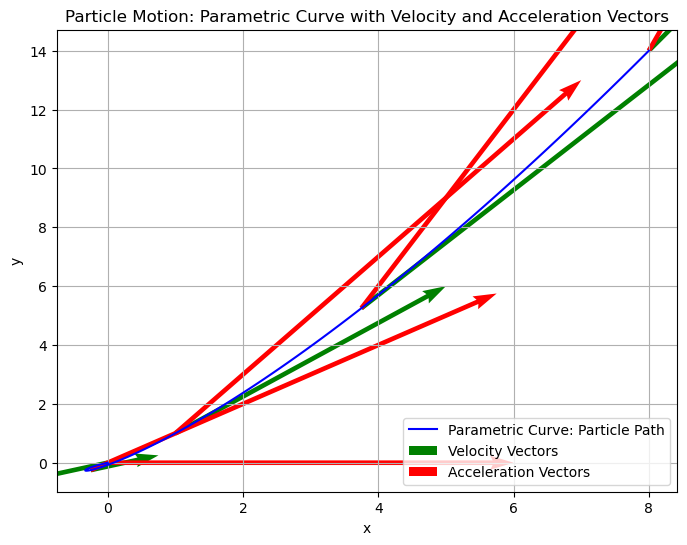

The length of the curve traced by the particle between t = 0 and t = 2 is approximately 17.10.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Define the parametric equations for x(t) and y(t)
def x(t):
    return 3 * t**2 - 2 * t

def y(t):
    return 2 * t**3 - t

# Define the velocity components
def v_x(t):
    return 6 * t - 2

def v_y(t):
    return 6 * t**2 - 1

# Define the acceleration components
def a_x(t):
    return 6

def a_y(t):
    return 12 * t

# Define the integrand for the length of the curve
def integrand(t):
    return np.sqrt(v_x(t)**2 + v_y(t)**2)

# Time range for plotting
t_vals = np.linspace(0, 2, 100)
x_vals = x(t_vals)
y_vals = y(t_vals)

# Plot the parametric curve
plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_vals, label='Parametric Curve: Particle Path', color='blue')

# Calculate and plot velocity and acceleration vectors at specific points
t_points = np.array([0, 0.5, 1, 1.5, 2])
v_x_vals = v_x(t_points)
v_y_vals = v_y(t_points)
a_x_vals = np.full_like(t_points, a_x(0))  # a_x is constant, so create an array with the same length
a_y_vals = a_y(t_points)

# Plot velocity vectors
plt.quiver(x(t_points), y(t_points), v_x_vals, v_y_vals, color='green', angles='xy', scale_units='xy', scale=1, label="Velocity Vectors")

# Plot acceleration vectors
plt.quiver(x(t_points), y(t_points), a_x_vals, a_y_vals, color='red', angles='xy', scale_units='xy', scale=1, label="Acceleration Vectors")

# Labels and Title
plt.xlabel('x')
plt.ylabel('y')
plt.title('Particle Motion: Parametric Curve with Velocity and Acceleration Vectors')
plt.grid(True)
plt.legend()
plt.show()

# Calculate the length of the curve numerically using integration
curve_length, _ = quad(integrand, 0, 2)
print(f"The length of the curve traced by the particle between t = 0 and t = 2 is approximately {curve_length:.2f}.")



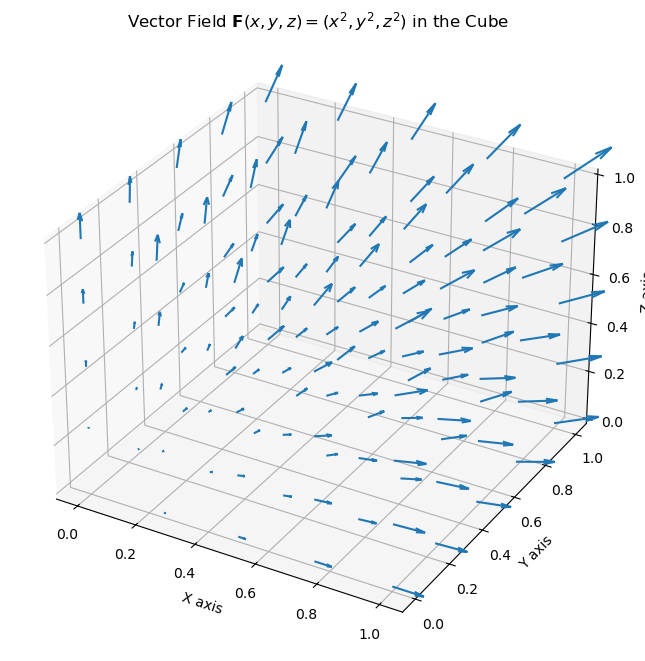

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a grid of points in the cube
x_vals, y_vals, z_vals = np.linspace(0, 1, 5), np.linspace(0, 1, 5), np.linspace(0, 1, 5)
X, Y, Z = np.meshgrid(x_vals, y_vals, z_vals)

# Define the vector field F(x, y, z) = (x^2, y^2, z^2)
# Vector field components
F_x = X**2  # x component of the vector field
F_y = Y**2  # y component of the vector field
F_z = Z**2  # z component of the vector field

# Plot the vector field using quiver
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.quiver(X, Y, Z, F_x, F_y, F_z, length=0.1)

# Set labels
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
ax.set_title('Vector Field $\\mathbf{F}(x, y, z) = (x^2, y^2, z^2)$ in the Cube')

plt.show()


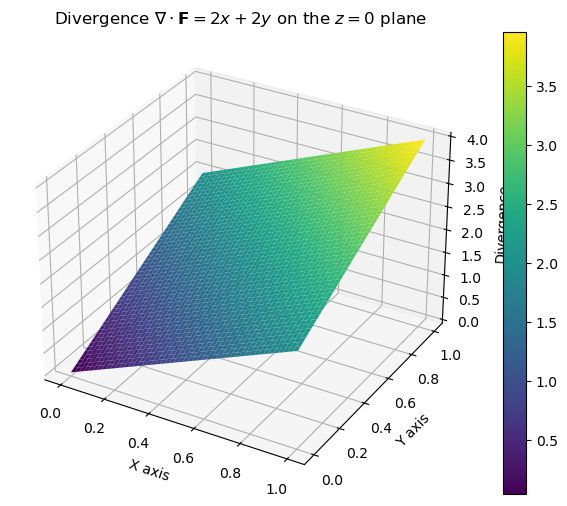

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a grid of points in the cube
n = 50  # Increase the grid density for a smoother surface plot
x_vals, y_vals = np.linspace(0, 1, n), np.linspace(0, 1, n)
X, Y = np.meshgrid(x_vals, y_vals)

# Calculate the divergence at z = 0 plane
Divergence_z0 = 2 * X + 2 * Y  # Since z = 0, the divergence simplifies to 2x + 2y

# Create a 3D surface plot for the divergence on z = 0 plane
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surface_plot = ax.plot_surface(X, Y, Divergence_z0, cmap='viridis', edgecolor='none')

# Add a color bar
fig.colorbar(surface_plot, ax=ax)

# Set labels
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Divergence')
ax.set_title('Divergence $\\nabla \\cdot \\mathbf{F} = 2x + 2y$ on the $z = 0$ plane')

plt.show()


In [6]:
from scipy.integrate import tplquad

# Define the divergence of the vector field
def divergence(x, y, z):
    return 2 * x + 2 * y + 2 * z

# Limits of the cube: x, y, z in [0, 1]
volume_integral, _ = tplquad(divergence, 0, 1, lambda x: 0, lambda x: 1, lambda x, y: 0, lambda x, y: 1)
print(f"Volume integral of the divergence: {volume_integral:.2f}")

Volume integral of the divergence: 3.00


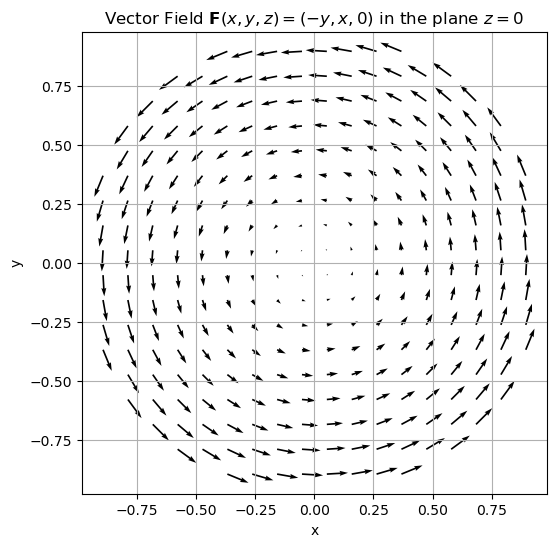

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Define the grid for the disk x^2 + y^2 <= 1
x_vals = np.linspace(-1, 1, 20)
y_vals = np.linspace(-1, 1, 20)
X, Y = np.meshgrid(x_vals, y_vals)

# Mask the points that lie outside the disk (x^2 + y^2 > 1)
mask = X**2 + Y**2 <= 1
X = X[mask]
Y = Y[mask]

# Define the vector field F(x, y, z) = (-y, x, 0) at z = 0
U = -Y  # x-component of the vector field
V = X   # y-component of the vector field

# Plot the vector field
plt.figure(figsize=(6,6))
plt.quiver(X, Y, U, V)
plt.title("Vector Field $\\mathbf{F}(x, y, z) = (-y, x, 0)$ in the plane $z = 0$")
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.axis('equal')
plt.show()


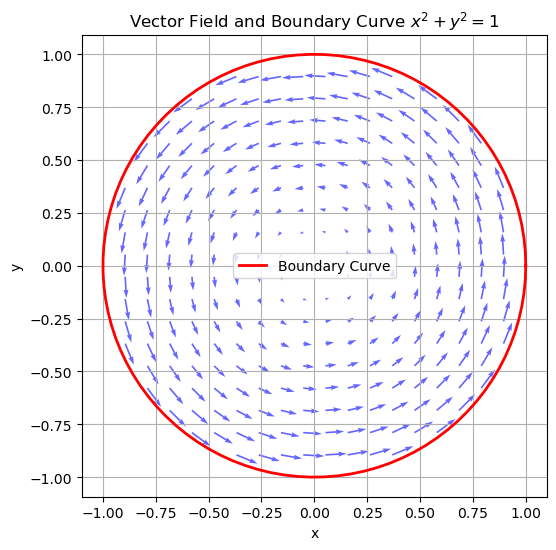

In [8]:
# Define the boundary curve (circle) x^2 + y^2 = 1
theta = np.linspace(0, 2*np.pi, 100)
x_circle = np.cos(theta)
y_circle = np.sin(theta)

# Plot the vector field and the boundary curve
plt.figure(figsize=(6,6))
plt.quiver(X, Y, U, V, color='blue', alpha=0.6)
plt.plot(x_circle, y_circle, color='red', linewidth=2, label='Boundary Curve')
plt.title("Vector Field and Boundary Curve $x^2 + y^2 = 1$")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

In [9]:
# Area of the disk
area_of_disk = np.pi * 1**2  # radius = 1
curl_z = 2  # curl in the z direction

# Surface integral of the curl
surface_integral = curl_z * area_of_disk
print(f"Surface integral of the curl: {surface_integral:.2f}")

Surface integral of the curl: 6.28


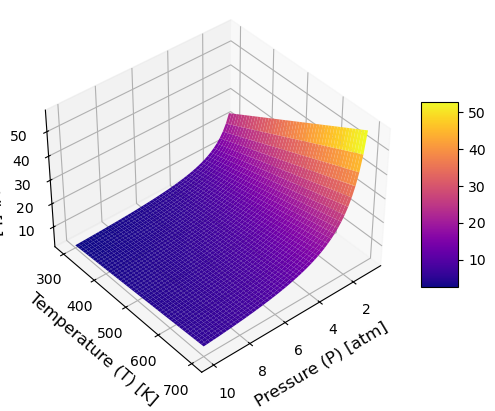

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a figure
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Define ranges for temperature (T) and pressure (P)
T = np.linspace(300, 700, 50)  # Temperature from 300K to 700K
P = np.linspace(1, 10, 50)     # Pressure from 1 to 10 atm
T, P = np.meshgrid(T, P)

# Equation for volume V, assume ideal gas law: PV = nRT
R = 0.0821  # L·atm/mol·K (Ideal gas constant)
n = 1       # Assume 1 mole of gas
V = (n * R * T) / P  # Ideal gas law rearranged to V = nRT / P

# Plot the surface in color
surf = ax.plot_surface(P, T, V, cmap='plasma', edgecolor='none')

# Color bar for the surface
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

# Label axes with units
ax.set_xlabel('Pressure (P) [atm]', fontsize=12)
ax.set_ylabel('Temperature (T) [K]', fontsize=12)
ax.set_zlabel('Volume (V) [L]', fontsize=12)

# Rotate the plot by 90 degrees
ax.view_init(elev=40, azim=50)  # azim=90 rotates it by 90 degrees

plt.show()


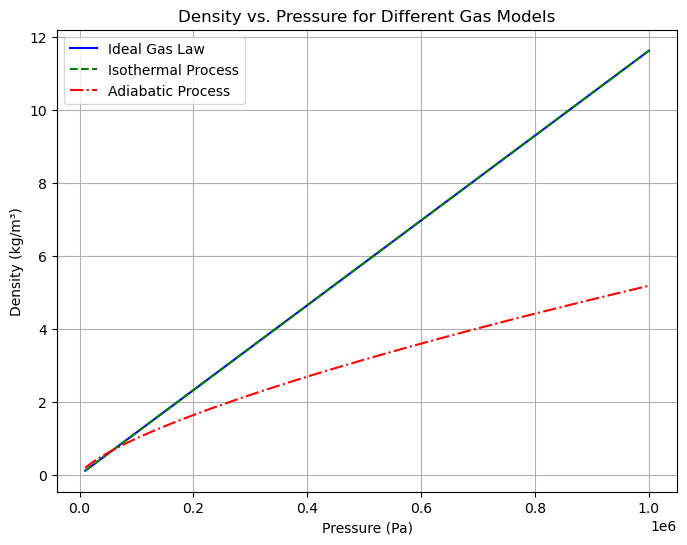

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
R = 287  # Specific gas constant for air in J/kg·K
T = 300  # Temperature in K (constant for isothermal and ideal gas law)
K = 1e5  # Constant for adiabatic process (specific to the gas)
gamma = 1.4  # Adiabatic index for air
P = np.linspace(1e4, 1e6, 500)  # Pressure range from 10 kPa to 1 MPa

# Ideal Gas Law: rho = P / (R * T)
rho_ideal = P / (R * T)

# Isothermal process (same as Ideal Gas for constant T)
rho_isothermal = P / (R * T)

# Adiabatic process: P = K * rho^gamma => rho = (P / K)^(1/gamma)
rho_adiabatic = (P / K) ** (1 / gamma)

# Plotting the results
plt.figure(figsize=(8, 6))

# Ideal Gas Law
plt.plot(P, rho_ideal, label="Ideal Gas Law", color='b')

# Isothermal Process
plt.plot(P, rho_isothermal, '--', label="Isothermal Process", color='g')

# Adiabatic Process
plt.plot(P, rho_adiabatic, '-.', label="Adiabatic Process", color='r')

# Labels and title
plt.title("Density vs. Pressure for Different Gas Models")
plt.xlabel("Pressure (Pa)")
plt.ylabel("Density (kg/m³)")
plt.legend()
plt.grid(True)

plt.show()


In [22]:
import plotly.express as px

df = px.data.iris()  # Load sample data
fig = px.scatter(df, x='sepal_width', y='sepal_length', color='species')
fig.show()

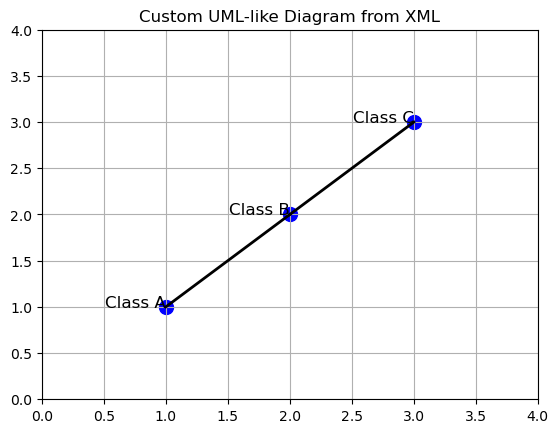

In [23]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

# Sample XML data as a string
xml_data = """
<diagram>
  <node id="1" label="Class A" x="1" y="1"/>
  <node id="2" label="Class B" x="2" y="2"/>
  <node id="3" label="Class C" x="3" y="3"/>
  <edge source="1" target="2"/>
  <edge source="2" target="3"/>
</diagram>
"""

# Parse the XML
root = ET.fromstring(xml_data)

# Initialize lists to store node and edge data
nodes = []
edges = []

# Extract node data
for node in root.findall('node'):
    id = node.get('id')
    label = node.get('label')
    x = float(node.get('x'))
    y = float(node.get('y'))
    nodes.append({'id': id, 'label': label, 'x': x, 'y': y})

# Extract edge data
for edge in root.findall('edge'):
    source = edge.get('source')
    target = edge.get('target')
    edges.append((source, target))

# Set up the plot
fig, ax = plt.subplots()

# Plot nodes
for node in nodes:
    ax.scatter(node['x'], node['y'], s=100, color='blue')
    ax.text(node['x'], node['y'], node['label'], fontsize=12, ha='right')

# Plot edges (as lines between nodes)
for edge in edges:
    source_node = next(node for node in nodes if node['id'] == edge[0])
    target_node = next(node for node in nodes if node['id'] == edge[1])
    ax.plot([source_node['x'], target_node['x']], [source_node['y'], target_node['y']], 'k-', lw=2)

# Customize plot
ax.set_title("Custom UML-like Diagram from XML")
ax.set_xlim(0, 4)
ax.set_ylim(0, 4)
ax.grid(True)

# Display the diagram
plt.show()